# Comparing v1.2 and v1.3 datasets

Compare attributes and images between `roman_data_challenge_rung_0_v_1_2.h5` and `roman_data_challenge_rung_0_v_1_3.h5`.

In [10]:
import os
os.environ.setdefault('HDF5_USE_FILE_LOCKING', 'FALSE')

import h5py
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import SymLogNorm
from tqdm.auto import tqdm

from mejiro.utils import util

In [11]:
label = 'roman_data_challenge_rung_0'
v12_filepath = f'/data/bwedig/mejiro/{label}/06/{label}_v_1_2.h5'
v13_filepath = f'/data/bwedig/mejiro/{label}/06/{label}_v_1_3.h5'

f_v12 = h5py.File(v12_filepath, 'r')
f_v13 = h5py.File(v13_filepath, 'r')

images_v12 = f_v12['images']
images_v13 = f_v13['images']

bands = ['F106', 'F129', 'F158']
band_colors = {'F106': 'tab:blue', 'F129': 'tab:green', 'F158': 'tab:red'}

print(f'v1.2: {len(images_v12)} systems')
print(f'v1.3: {len(images_v13)} systems')

v1.2: 11160 systems
v1.3: 11160 systems


## Root attribute differences

In [12]:
def attr_value(attrs, key):
    v = attrs[key]
    if isinstance(v, np.ndarray):
        return v[0] if v.size > 0 else v
    return v

def diff_attrs(a, b, label_a='a', label_b='b'):
    keys = sorted(set(a.keys()) | set(b.keys()))
    rows = []
    for k in keys:
        va = attr_value(a, k) if k in a else '<missing>'
        vb = attr_value(b, k) if k in b else '<missing>'
        if str(va) != str(vb):
            rows.append((k, va, vb))
    if not rows:
        print('  (no differences)')
        return
    width = max(len(k) for k, _, _ in rows)
    print(f'  {"key".ljust(width)}  {label_a}  ->  {label_b}')
    for k, va, vb in rows:
        print(f'  {k.ljust(width)}  {va}  ->  {vb}')

print('Root attribute differences:')
diff_attrs(f_v12.attrs, f_v13.attrs, 'v1.2', 'v1.3')

Root attribute differences:
  key                  v1.2  ->  v1.3
  author               bwedig@galileo.physics.wustl.edu  ->  bwedig@parsley.physics.wustl.edu
  created              2025_10_31-11_26_28_AM  ->  2026_05_19-01_47_54_PM
  galsim_version       2.5.1  ->  2.7.2
  lenstronomy_version  1.13.2  ->  1.13.3
  mejiro_version       2.0.0  ->  3.0.0
  slsim_version        0.1.0  ->  0.1.1


## System and dataset attribute differences

For every shared system, count which attribute keys differ. Reports counts across all systems and shows an example diff.

In [13]:
from collections import Counter

common_keys = sorted(set(images_v12.keys()) & set(images_v13.keys()))
only_v12 = sorted(set(images_v12.keys()) - set(images_v13.keys()))
only_v13 = sorted(set(images_v13.keys()) - set(images_v12.keys()))
print(f'Common systems: {len(common_keys)}')
print(f'Only in v1.2: {len(only_v12)}')
print(f'Only in v1.3: {len(only_v13)}')

sys_diff_counter = Counter()
ds_diff_counter = Counter()
first_sys_diff = None
first_ds_diff = None

for key in tqdm(common_keys):
    sl12 = images_v12[key]
    sl13 = images_v13[key]

    sys_keys = set(sl12.attrs.keys()) | set(sl13.attrs.keys())
    for ak in sys_keys:
        va = attr_value(sl12.attrs, ak) if ak in sl12.attrs else None
        vb = attr_value(sl13.attrs, ak) if ak in sl13.attrs else None
        if str(va) != str(vb):
            sys_diff_counter[ak] += 1
            if first_sys_diff is None:
                first_sys_diff = key

    for band in bands:
        uid = attr_value(sl12.attrs, 'uid')
        ds_name = f'exposure_{uid}_{band}'
        if ds_name not in sl12 or ds_name not in sl13:
            continue
        a12 = sl12[ds_name].attrs
        a13 = sl13[ds_name].attrs
        ds_keys = set(a12.keys()) | set(a13.keys())
        for ak in ds_keys:
            va = attr_value(a12, ak) if ak in a12 else None
            vb = attr_value(a13, ak) if ak in a13 else None
            if str(va) != str(vb):
                ds_diff_counter[ak] += 1
                if first_ds_diff is None:
                    first_ds_diff = (key, ds_name)

print('\nSystem-level attrs that differ (count of systems differing):')
for k, n in sys_diff_counter.most_common():
    print(f'  {k}: {n}')

print('\nDataset-level attrs that differ (count of exposures differing):')
for k, n in ds_diff_counter.most_common():
    print(f'  {k}: {n}')

Common systems: 11160
Only in v1.2: 0
Only in v1.3: 0


  0%|          | 0/11160 [00:00<?, ?it/s]


System-level attrs that differ (count of systems differing):
  detector_position_y: 11160
  detector_position_x: 11160

Dataset-level attrs that differ (count of exposures differing):
  snr: 33480
  fov: 33480


In [14]:
if first_sys_diff is not None:
    print(f'Example system attr diff ({first_sys_diff}):')
    diff_attrs(images_v12[first_sys_diff].attrs, images_v13[first_sys_diff].attrs, 'v1.2', 'v1.3')

if first_ds_diff is not None:
    key, ds_name = first_ds_diff
    print(f'\nExample dataset attr diff ({key}/{ds_name}):')
    diff_attrs(images_v12[key][ds_name].attrs, images_v13[key][ds_name].attrs, 'v1.2', 'v1.3')

Example system attr diff (strong_lens_00000000):
  key                  v1.2  ->  v1.3
  detector_position_x  409  ->  2554
  detector_position_y  2044  ->  1532

Example dataset attr diff (strong_lens_00000000/exposure_00000000_F106):
  key  v1.2  ->  v1.3
  fov  10.01  ->  8.03
  snr  20.435625947519355  ->  20.932320192467458


## Image differences

v1.2 images are 91x91 (FOV 10.01") and v1.3 are 73x73 (FOV 8.03"); both are in Counts. Crop v1.2 to the v1.3 footprint, then compare per-pixel.

In [15]:
resid_stats = {band: {'median_abs': [], 'max_abs': [], 'rel_l1': []} for band in bands}
chi2_vals = {band: [] for band in bands}

for key in tqdm(common_keys):
    sl12 = images_v12[key]
    sl13 = images_v13[key]
    uid = attr_value(sl12.attrs, 'uid')

    for band in bands:
        ds_name = f'exposure_{uid}_{band}'
        if ds_name not in sl12 or ds_name not in sl13:
            continue
        img12 = sl12[ds_name][:]
        img13 = sl13[ds_name][:]

        if img12.shape != img13.shape:
            img12 = util.center_crop_image(img12, img13.shape)

        resid = img13 - img12
        resid_stats[band]['median_abs'].append(float(np.median(np.abs(resid))))
        resid_stats[band]['max_abs'].append(float(np.max(np.abs(resid))))
        denom = float(np.sum(np.abs(img12)))
        resid_stats[band]['rel_l1'].append(float(np.sum(np.abs(resid)) / denom) if denom > 0 else np.nan)

        mask = img12 > 0
        chi2 = (resid[mask] ** 2) / img12[mask]
        chi2_vals[band].append(chi2.ravel())

for band in bands:
    ma = np.array(resid_stats[band]['median_abs'])
    mx = np.array(resid_stats[band]['max_abs'])
    rl = np.array(resid_stats[band]['rel_l1'])
    print(f'{band}: N={ma.size}  '
          f'median |v13-v12| (median over systems) = {np.median(ma):.4g} Counts,  '
          f'max |v13-v12| (median over systems) = {np.median(mx):.4g} Counts,  '
          f'rel L1 (median) = {np.nanmedian(rl):.4g}')

chi2_vals = {band: np.concatenate(arrs) for band, arrs in chi2_vals.items() if arrs}
for band, arr in chi2_vals.items():
    print(f'{band}: {arr.size} pixels, median chi2 = {np.median(arr):.4f}, mean chi2 = {np.mean(arr):.4f}')

  0%|          | 0/11160 [00:00<?, ?it/s]

F106: N=11160  median |v13-v12| (median over systems) = 23 Counts,  max |v13-v12| (median over systems) = 144 Counts,  rel L1 (median) = 0.08325
F129: N=11160  median |v13-v12| (median over systems) = 23 Counts,  max |v13-v12| (median over systems) = 156 Counts,  rel L1 (median) = 0.08308
F158: N=11160  median |v13-v12| (median over systems) = 22 Counts,  max |v13-v12| (median over systems) = 167 Counts,  rel L1 (median) = 0.07799
F106: 59471640 pixels, median chi2 = 1.6741, mean chi2 = 3.2610
F129: 59471640 pixels, median chi2 = 1.6519, mean chi2 = 3.2590
F158: 59471640 pixels, median chi2 = 1.5031, mean chi2 = 3.0930


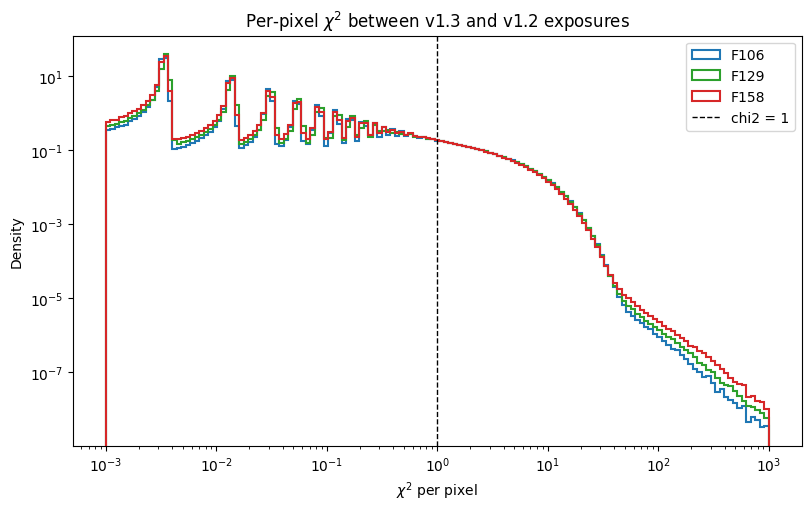

In [16]:
fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)
bin_edges = np.logspace(-3, 3, 150)
for band in bands:
    if band not in chi2_vals:
        continue
    ax.hist(chi2_vals[band], bins=bin_edges, histtype='step', linewidth=1.5,
            color=band_colors[band], label=band, density=True)
ax.set_xscale('log')
ax.set_yscale('log')
ax.axvline(1, color='k', linestyle='--', linewidth=1, label='chi2 = 1')
ax.set_xlabel(r'$\chi^2$ per pixel')
ax.set_ylabel('Density')
ax.set_title(r'Per-pixel $\chi^2$ between v1.3 and v1.2 exposures')
ax.legend()
plt.show()

## Example exposures: v1.2, v1.3, and residual

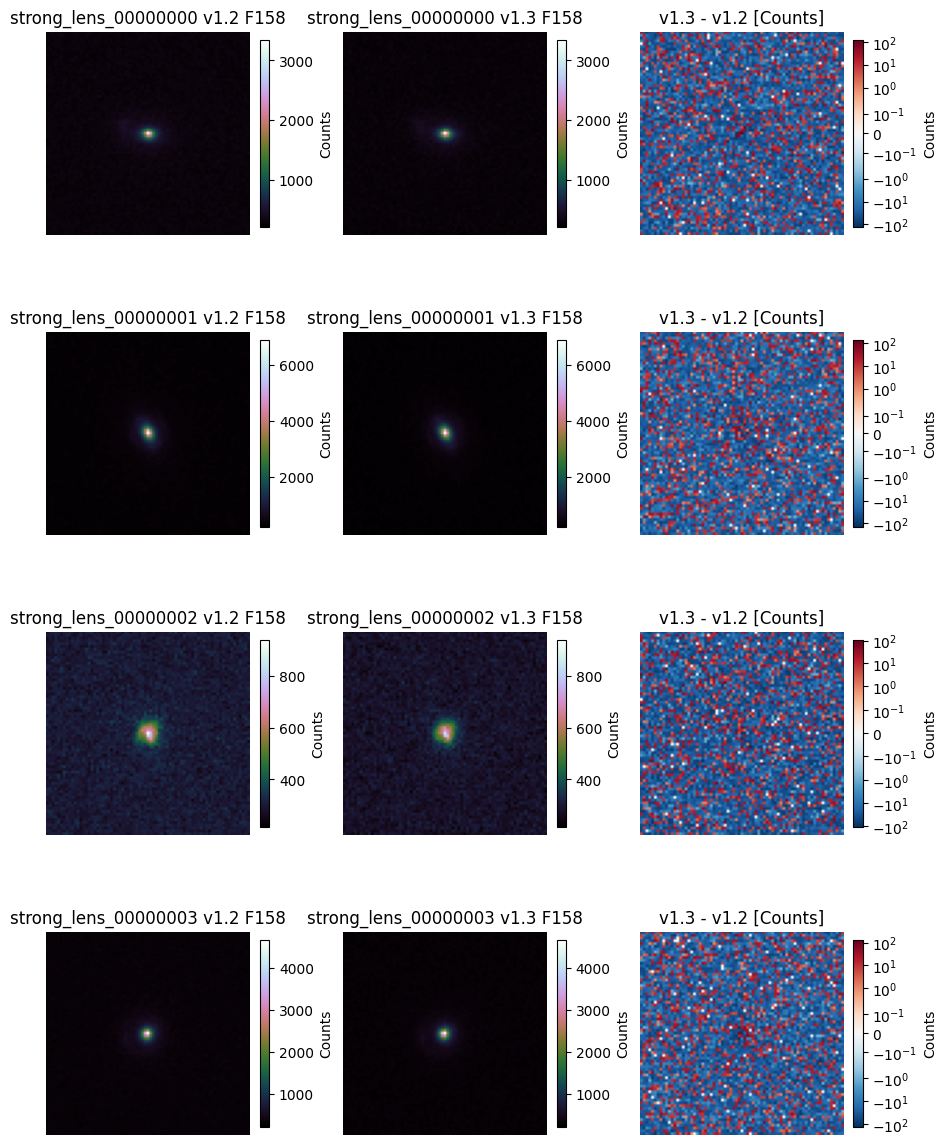

In [17]:
n_examples = 4
example_keys = common_keys[:n_examples]
band = 'F158'

fig, axes = plt.subplots(n_examples, 3, figsize=(9, 3 * n_examples), constrained_layout=True)
if n_examples == 1:
    axes = axes[np.newaxis, :]

for row, key in enumerate(example_keys):
    uid = attr_value(images_v12[key].attrs, 'uid')
    ds_name = f'exposure_{uid}_{band}'
    img12 = images_v12[key][ds_name][:]
    img13 = images_v13[key][ds_name][:]
    if img12.shape != img13.shape:
        img12 = util.center_crop_image(img12, img13.shape)
    residual = img13 - img12

    vmin = min(img12.min(), img13.min())
    vmax = max(img12.max(), img13.max())
    rmax = float(np.max(np.abs(residual))) or 1e-6
    rlin = max(rmax * 1e-3, 1e-6)

    im0 = axes[row, 0].imshow(img12, origin='lower', cmap='cubehelix', vmin=vmin, vmax=vmax)
    axes[row, 0].set_title(f'{key} v1.2 {band}')
    plt.colorbar(im0, ax=axes[row, 0], fraction=0.046, label='Counts')

    im1 = axes[row, 1].imshow(img13, origin='lower', cmap='cubehelix', vmin=vmin, vmax=vmax)
    axes[row, 1].set_title(f'{key} v1.3 {band}')
    plt.colorbar(im1, ax=axes[row, 1], fraction=0.046, label='Counts')

    im2 = axes[row, 2].imshow(residual, origin='lower', cmap='RdBu_r',
                              norm=SymLogNorm(linthresh=rlin, vmin=-rmax, vmax=rmax))
    axes[row, 2].set_title('v1.3 - v1.2 [Counts]')
    plt.colorbar(im2, ax=axes[row, 2], fraction=0.046, label='Counts')

    for a in axes[row]:
        a.axis('off')

plt.show()

In [18]:
f_v12.close()
f_v13.close()